# Exercise 2 — Feature Importance

**PCS956 • Module C • Week 1**

## Research question

**When a decision tree assigns importance to a feature, what exactly does that importance represent, and how stable is the ranking?**

In this exercise, we will:

- fit a decision tree using the same Titanic prediction task as Exercise 1;
- compute impurity-based feature importance;
- distinguish importance of encoded columns from importance of the original variables;
- connect feature importance back to the fitted tree;
- examine how the ranking changes with tree complexity;
- examine stability under bootstrap resampling; and
- discuss the main limitations of impurity-based importance.

This exercise focuses on **global model inspection**.


## 1. Imports


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.tree import DecisionTreeClassifier, plot_tree


## 2. Prepare the Titanic data

We use the same variables and train/test split strategy as in Exercise 1, so the exploratory visualisations are not repeated here.

The target is:

- `survived = 0` — did not survive;
- `survived = 1` — survived.

The predictors are:

`pclass`, `sex`, `age`, `sibsp`, `parch`, `fare`, and `embarked`.

Preprocessing is fitted only on the training data and then applied to the test data.

For categorical variables, all one-hot encoded categories are retained. Therefore, `sex` becomes both:

- `sex_female`
- `sex_male`

and `embarked` becomes:

- `embarked_C`
- `embarked_Q`
- `embarked_S`

Because `sex_female` and `sex_male` are exact complements, a tree can express the same binary partition using either column. This matters when interpreting feature-importance values for the encoded representation.


In [2]:
RANDOM_STATE = 42

# Load the dataset.
titanic = sns.load_dataset("titanic")

# Predictor variables and target.
FEATURES = [
    "pclass",
    "sex",
    "age",
    "sibsp",
    "parch",
    "fare",
    "embarked"
]

TARGET = "survived"

X = titanic[FEATURES].copy()
y = titanic[TARGET].copy()

# Split before fitting preprocessing.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

# Numerical and categorical variables use different preprocessing.
numeric_features = [
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

categorical_features = [
    "sex",
    "embarked"
]

# Replace missing numerical values with the training-set median.
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

# Replace missing categorical values with the most frequent category,
# then create one binary indicator column for every category.
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ],
    verbose_feature_names_out=False
)

# Learn preprocessing from the training data only.
X_train = preprocessor.fit_transform(X_train_raw)

# Apply the fitted preprocessing to the test data.
X_test = preprocessor.transform(X_test_raw)

feature_names = preprocessor.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names,
    index=X_train_raw.index
)

X_test_df = pd.DataFrame(
    X_test,
    columns=feature_names,
    index=X_test_raw.index
)

print("Training observations:", len(X_train_df))
print("Test observations:", len(X_test_df))
print("Transformed features:")
print(list(feature_names))


Training observations: 712
Test observations: 179
Transformed features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']


### Encoded representation

The tree operates on the transformed columns, not directly on the original categorical strings.

For example:

- `sex_female = 1` means the passenger is encoded as female;
- `sex_male = 1` means the passenger is encoded as male.

Only one of those two columns can be 1 for a given passenger.

Feature importance can therefore be discussed at two levels:

1. **encoded-column level** — for example, `sex_female` and `sex_male` separately;
2. **original-variable level** — for example, the combined importance associated with `sex`.

Both views are useful, but they answer slightly different questions.


## 3. Fit a decision tree

We use a tree with `max_depth=4`.

The feature-importance values computed later belong specifically to this fitted tree.


In [3]:
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=RANDOM_STATE
)

tree_model.fit(
    X_train_df,
    y_train
)

train_pred = tree_model.predict(
    X_train_df
)

test_pred = tree_model.predict(
    X_test_df
)

print(
    "Training accuracy:",
    round(
        accuracy_score(
            y_train,
            train_pred
        ),
        3
    )
)

print(
    "Test accuracy:",
    round(
        accuracy_score(
            y_test,
            test_pred
        ),
        3
    )
)

print(
    "Test balanced accuracy:",
    round(
        balanced_accuracy_score(
            y_test,
            test_pred
        ),
        3
    )
)

print(
    "Tree depth:",
    tree_model.get_depth()
)

print(
    "Number of nodes:",
    tree_model.tree_.node_count
)

print(
    "Number of leaves:",
    tree_model.get_n_leaves()
)


Training accuracy: 0.841
Test accuracy: 0.793
Test balanced accuracy: 0.748
Tree depth: 4
Number of nodes: 29
Number of leaves: 15


### Why report model performance first?

Feature importance should not be interpreted in isolation.

Before discussing which inputs the model relied on, we should know:

- which model produced the ranking;
- how complex that fitted model is; and
- how well it performs on held-out data.

An importance ranking explains aspects of the fitted model. It does not establish that the model itself is correct.


## 4. Impurity-based feature importance

For a scikit-learn decision tree, `feature_importances_` measures the **normalised total reduction in the splitting criterion** attributed to each feature across the fitted tree.

With the default classification criterion, this is commonly called **Gini importance** or **mean decrease in impurity (MDI)**.

A larger value means that the fitted tree assigned more of its weighted impurity reduction to that feature.


In [4]:
# Importance of each transformed input column.
encoded_importance = pd.Series(
    tree_model.feature_importances_,
    index=feature_names
).sort_values(
    ascending=False
)

encoded_importance_table = (
    encoded_importance
    .rename("importance")
    .reset_index()
    .rename(
        columns={
            "index": "feature"
        }
    )
)

display(
    encoded_importance_table
)

print(
    "Sum of encoded importances:",
    round(
        encoded_importance.sum(),
        6
    )
)


,feature,importance
0,sex_female,0.576297
1,pclass,0.195920
2,age,0.114526
3,fare,0.063141
4,embarked_S,0.037198
5,sibsp,0.012109
6,parch,0.000809
7,sex_male,0.000000
8,embarked_C,0.000000
9,embarked_Q,0.000000


Sum of encoded importances: 1.0


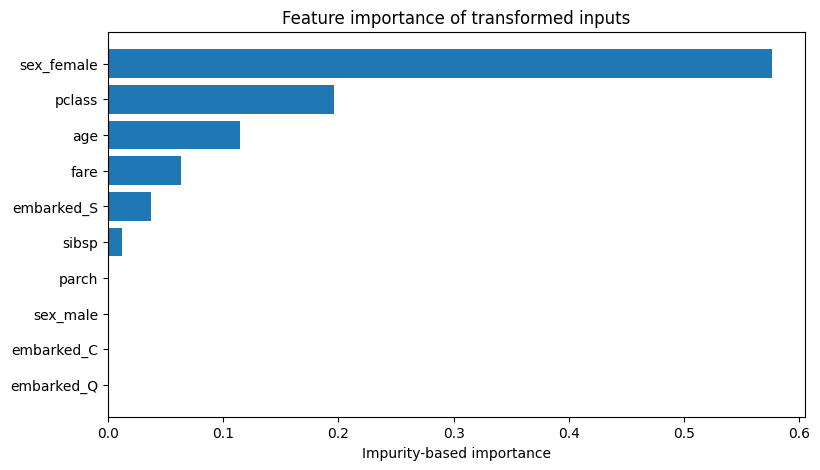

In [5]:
plt.figure(figsize=(9, 5))

plt.barh(
    encoded_importance_table["feature"][::-1],
    encoded_importance_table["importance"][::-1]
)

plt.xlabel(
    "Impurity-based importance"
)

plt.title(
    "Feature importance of transformed inputs"
)

plt.show()


### Interpreting the encoded ranking

The ranking above describes the **transformed columns used by this fitted tree**.

For example, `sex_female` and `sex_male` are two encodings of the same original binary variable. Because they are complementary, the tree may use one rather than the other to express essentially the same split.

Therefore:

> A difference between the importance of `sex_female` and `sex_male` should not be interpreted as evidence that one category is intrinsically more important than the other.

For categorical variables represented by several one-hot columns, it is often useful to also inspect importance at the original-variable level.


## 5. Group importance back to the original variables

To obtain an original-variable summary, we combine the impurity importance of one-hot encoded columns that came from the same categorical variable.

Here:

- `sex_female` + `sex_male` → `sex`
- `embarked_C` + `embarked_Q` + `embarked_S` → `embarked`

The numerical variables already correspond directly to their original variables.

This grouping is a summary of the fitted model's encoded importances. It does not remove the limitations of impurity-based importance.


In [6]:
def original_feature_name(encoded_feature):
    # Map one-hot encoded columns back to their original variable.
    if encoded_feature.startswith("sex_"):
        return "sex"

    if encoded_feature.startswith("embarked_"):
        return "embarked"

    # Numerical features already use their original names.
    return encoded_feature


grouped_importance_table = (
    encoded_importance_table
    .assign(
        original_feature=lambda df:
            df["feature"].map(
                original_feature_name
            )
    )
    .groupby(
        "original_feature",
        as_index=False
    )["importance"]
    .sum()
    .sort_values(
        "importance",
        ascending=False
    )
)

display(
    grouped_importance_table
)


,original_feature,importance
5,sex,0.576297
4,pclass,0.195920
0,age,0.114526
2,fare,0.063141
1,embarked,0.037198
6,sibsp,0.012109
3,parch,0.000809


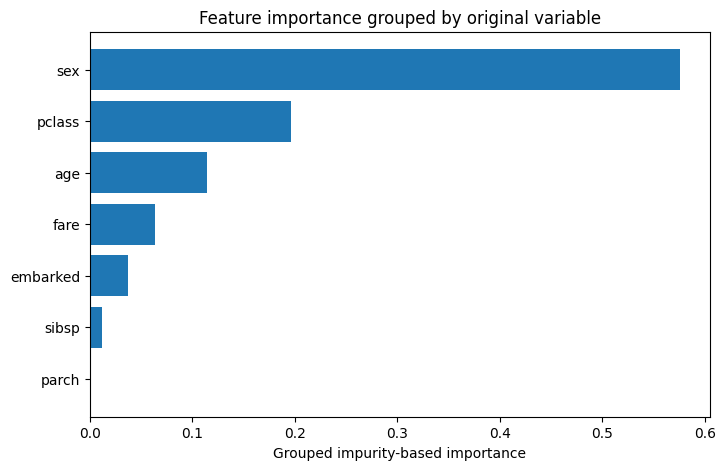

In [7]:
plt.figure(figsize=(8, 5))

plot_table = (
    grouped_importance_table
    .sort_values(
        "importance",
        ascending=True
    )
)

plt.barh(
    plot_table["original_feature"],
    plot_table["importance"]
)

plt.xlabel(
    "Grouped impurity-based importance"
)

plt.title(
    "Feature importance grouped by original variable"
)

plt.show()


### What does the grouped ranking mean?

The grouped value for `sex`, for example, is the sum of the impurity reductions attributed to `sex_female` and `sex_male`.

This gives a representation-level summary closer to the original variable.

It still means only:

> **This fitted tree used that original variable to account for a certain share of its total weighted impurity reduction.**

It does not mean that the variable has that amount of causal influence on survival.


## 6. Connect feature importance back to the tree

Feature importance is calculated from the splits used by the fitted tree.

Inspecting the tree helps connect the numerical ranking to the model structure.


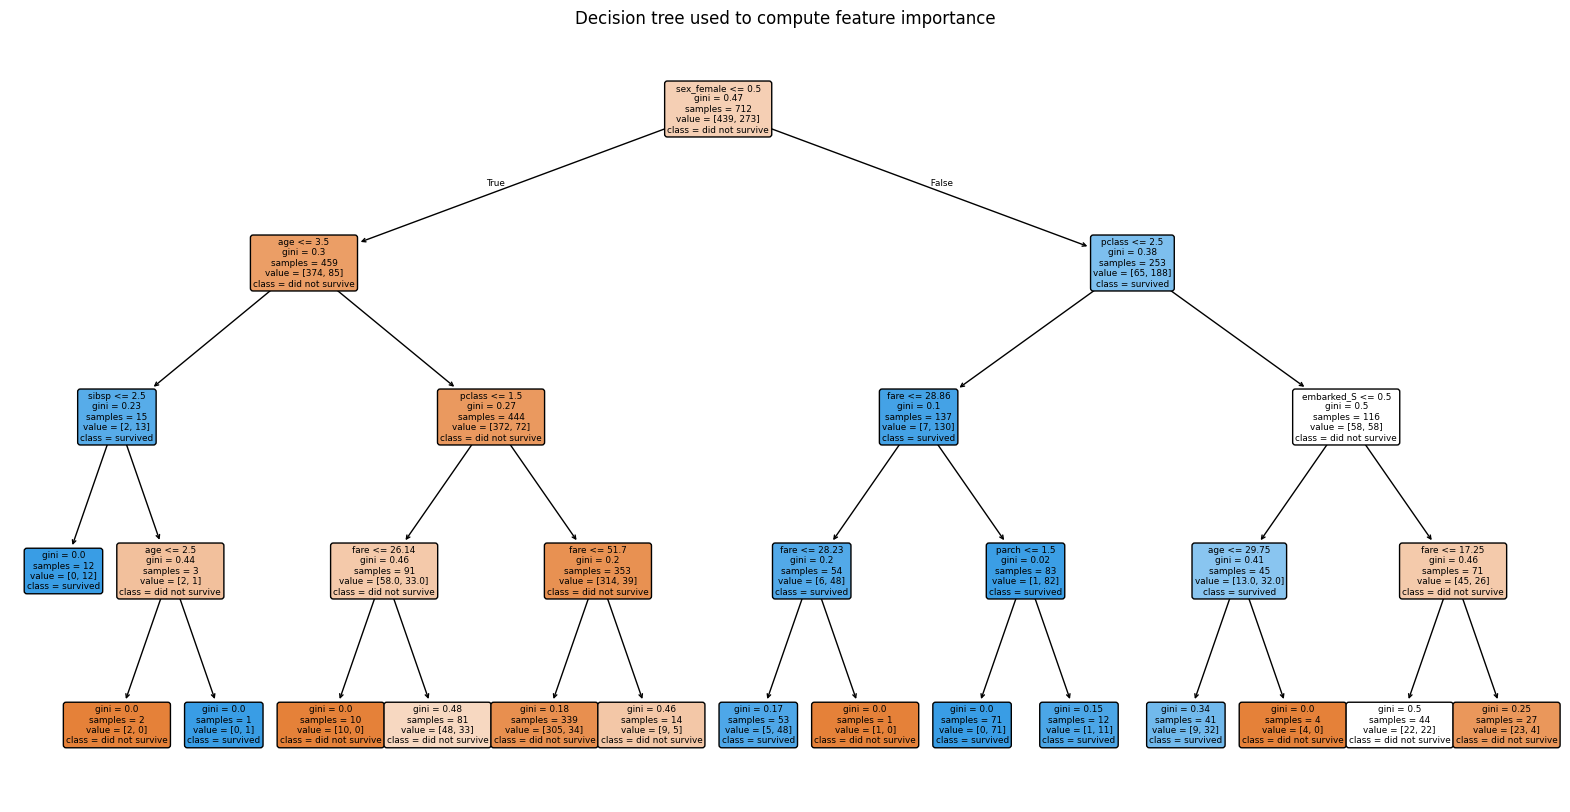

In [8]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_model,
    feature_names=feature_names,
    class_names=[
        "did not survive",
        "survived"
    ],
    filled=True,
    rounded=True,
    impurity=True,
    precision=2
)

plt.title(
    "Decision tree used to compute feature importance"
)

plt.show()


### What to look for

Compare the tree with the importance ranking.

Ask:

- Which features appear near the top of the tree?
- Which features are used more than once?
- Which splits affect relatively many training observations?
- Which encoded columns are never used?

A feature with zero impurity importance means:

> **This fitted tree did not use that encoded column in any impurity-reducing split.**

It does **not** mean that the original variable is unrelated to the outcome or useless in every possible model.


## 7. Does importance change with tree complexity?

Feature importance is a property of a **particular fitted model**.

Changing `max_depth` changes the set of splits that the tree is allowed to learn. We therefore compare grouped original-variable importance across several tree depths.


In [9]:
depth_values = [
    2,
    3,
    4,
    5,
    None
]

depth_records = []

for max_depth in depth_values:
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=RANDOM_STATE
    )

    model.fit(
        X_train_df,
        y_train
    )

    for encoded_feature, value in zip(
        feature_names,
        model.feature_importances_
    ):
        depth_records.append({
            "max_depth":
                "None"
                if max_depth is None
                else str(max_depth),
            "encoded_feature":
                encoded_feature,
            "original_feature":
                original_feature_name(
                    encoded_feature
                ),
            "importance":
                value
        })

importance_by_depth = pd.DataFrame(
    depth_records
)

grouped_depth_importance = (
    importance_by_depth
    .groupby(
        [
            "original_feature",
            "max_depth"
        ],
        as_index=False
    )["importance"]
    .sum()
)

pivot_importance = (
    grouped_depth_importance
    .pivot(
        index="original_feature",
        columns="max_depth",
        values="importance"
    )
    .fillna(0)
)

display(
    pivot_importance
)


max_depth,2,3,4,5,None
original_feature,,,,,
age,0.101970,0.090145,0.114526,0.128719,0.269790
embarked,0.000000,0.041015,0.037198,0.034252,0.038921
fare,0.000000,0.004019,0.063141,0.114076,0.234916
parch,0.000000,0.000000,0.000809,0.000745,0.012106
pclass,0.179231,0.216027,0.195920,0.180404,0.109693
sex,0.718799,0.635442,0.576297,0.530655,0.315047
sibsp,0.000000,0.013352,0.012109,0.011150,0.019526


### Interpretation

If the ranking changes with tree depth, that is expected.

Changing the depth can change:

- which variables are selected;
- where they appear in the tree;
- how often they are reused; and
- how much weighted impurity reduction is attributed to them.

Therefore, feature importance is not a fixed property of the dataset.


## 8. Stability under bootstrap resampling

A single fitted tree gives one importance ranking.

To examine how sensitive that ranking is to the training sample, we repeatedly:

1. draw a bootstrap sample from the training data;
2. fit another depth-4 tree;
3. compute impurity-based importance;
4. group the encoded columns back to the original variables.

This produces a distribution of importance values across plausible refits.


In [10]:
rng = np.random.default_rng(
    RANDOM_STATE
)

bootstrap_records = []

for run in range(40):
    # Sample training rows with replacement.
    bootstrap_positions = rng.integers(
        0,
        len(X_train_df),
        size=len(X_train_df)
    )

    X_boot = X_train_df.iloc[
        bootstrap_positions
    ]

    y_boot = y_train.iloc[
        bootstrap_positions
    ]

    model = DecisionTreeClassifier(
        max_depth=4,
        random_state=run
    )

    model.fit(
        X_boot,
        y_boot
    )

    # Store importance at the original-variable level.
    run_records = []

    for encoded_feature, value in zip(
        feature_names,
        model.feature_importances_
    ):
        run_records.append({
            "original_feature":
                original_feature_name(
                    encoded_feature
                ),
            "importance":
                value
        })

    run_df = pd.DataFrame(
        run_records
    )

    grouped_run = (
        run_df
        .groupby(
            "original_feature",
            as_index=False
        )["importance"]
        .sum()
    )

    grouped_run["run"] = run

    bootstrap_records.append(
        grouped_run
    )

bootstrap_importance = pd.concat(
    bootstrap_records,
    ignore_index=True
)

importance_summary = (
    bootstrap_importance
    .groupby(
        "original_feature"
    )["importance"]
    .agg(
        [
            "mean",
            "std",
            "min",
            "max"
        ]
    )
    .sort_values(
        "mean",
        ascending=False
    )
)

display(
    importance_summary
)


,mean,std,min,max
original_feature,,,,
sex,0.543813,0.054002,0.392418,0.619705
pclass,0.164788,0.042956,0.082024,0.245802
age,0.135400,0.035328,0.057506,0.232536
fare,0.104101,0.050941,0.025155,0.242231
embarked,0.023475,0.025106,0.000000,0.071226
sibsp,0.019263,0.020572,0.000000,0.070015
parch,0.009160,0.013959,0.000000,0.049523


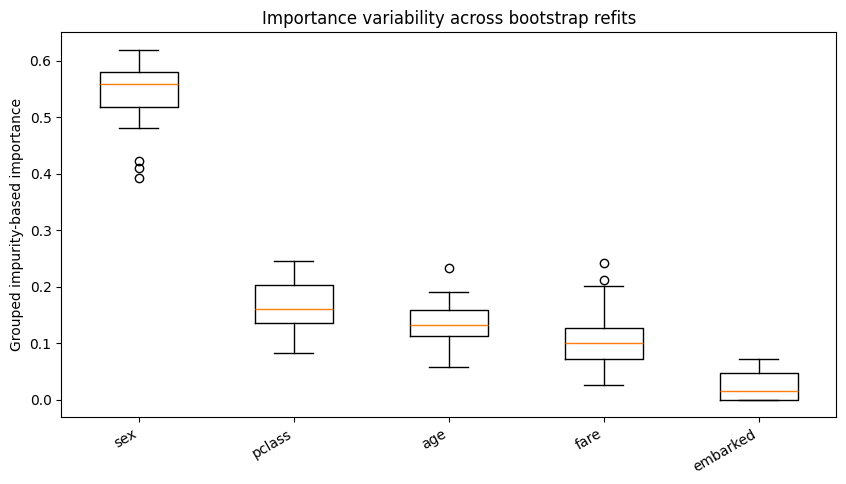

In [11]:
top_features = list(
    importance_summary
    .head(5)
    .index
)

plot_data = [
    bootstrap_importance.loc[
        bootstrap_importance[
            "original_feature"
        ] == feature,
        "importance"
    ].values
    for feature in top_features
]

plt.figure(figsize=(10, 5))

plt.boxplot(
    plot_data,
    tick_labels=top_features
)

plt.ylabel(
    "Grouped impurity-based importance"
)

plt.title(
    "Importance variability across bootstrap refits"
)

plt.xticks(
    rotation=30,
    ha="right"
)

plt.show()


### Interpretation

The mean describes the average importance across bootstrap refits, while the spread shows how much the estimate varies when the training sample changes.

A narrow distribution indicates greater stability under this resampling procedure.

A wide distribution indicates that the importance assigned to that variable is more sample-sensitive.

This is a stability analysis of the **importance measure for this modelling setup**. It does not establish causal importance.


## 9. Scientific cautions

Keep the following points in mind.

### 1. Model dependence

The ranking belongs to the fitted decision tree. A different model or different hyperparameters may produce a different ranking.

### 2. Representation dependence

Categorical variables are represented using one-hot encoded columns. With redundant encodings such as `sex_female` and `sex_male`, importance can be assigned to either encoded column even though both represent the same original binary variable.

### 3. No causal interpretation

Feature importance describes how the fitted model used its inputs. It does not tell us what would happen if we intervened and changed a real-world variable.

### 4. Correlated or redundant predictors

When several predictors contain overlapping information, a tree may select one and assign little or no importance to another.

### 5. Bias of impurity-based importance

Impurity-based importance can favour variables with many possible split points, such as continuous or high-cardinality features.

For these reasons, the ranking should be treated as a model-inspection summary rather than a definitive scientific ordering of variables.


## 10. Student task

Choose two tree depths from:

- `max_depth=2`
- `max_depth=4`
- `max_depth=5`

For each tree:

1. fit the model using the same training data;
2. report test accuracy and balanced accuracy;
3. calculate feature importance;
4. group the encoded columns back to the original variables;
5. report the three highest-ranked original variables;
6. compare the two rankings.

Then answer:

- Which variables changed position in the ranking?
- Did any variable's importance change substantially?
- How did the tree structure change?
- Why does this show that feature importance is a property of the fitted model rather than a fixed property of the dataset?
- Why should the ranking not be interpreted causally?


## 11. Questions for discussion

1. What exactly does a large impurity-based importance value mean?
2. Why can `sex_female` and `sex_male` receive different encoded importances even though they represent the same binary variable?
3. Why is grouping one-hot columns useful when discussing the original variables?
4. Why does zero importance not mean that a variable is scientifically irrelevant?
5. Why can changing tree depth change the ranking?
6. Why can bootstrap refits change the ranking?
7. How can redundant or correlated predictors affect importance?
8. Why should impurity-based importance not be interpreted as causal evidence?


## 12. Takeaway

Impurity-based feature importance is a **global summary of how a fitted decision tree distributes weighted impurity reduction across its input features**.

In this exercise:

- encoded-column importance describes the transformed representation used by the tree;
- grouped importance provides a summary at the level of the original variables;
- the ranking depends on the fitted model and its complexity;
- bootstrap refitting can reveal how stable the ranking is to changes in the training sample;
- zero importance has a model-specific interpretation; and
- feature importance does not establish causal effect.

The importance ranking is therefore useful for model inspection, but it should be interpreted in the context of the fitted model, feature representation, and analysis setup.
